# Mixture Models for Semiconductor Leakage and Yield



### Project layout

The notebook is organized as follows.

| Section | Content |
|--------|---------|
| §1 | Introduction and basic statistics for the synthetic lot–wafer dataset |
| §2 | Setup and configuration (libraries, plotting) |
| §3 | Exploratory data analysis (EDA) of humidity, leakage, and yield by lot |
| §4 | Baseline pooled linear model (ignoring lot structure) |
| §5 | Random intercept mixed model with lot‑level effects |
| §6 | Comparing models for new predictions (unseen lots / wafers) |
| §7 | Comparing models when some lot data exist (BLUPs) |
| §8 | Evaluation, theory/code summary, and possible extensions |

Each section starts with a short explanation of the objective, a brief description before each code block explaining *why* we run it, and a short interpretation after each result.

## 1. Introduction and basic statistics



## 2. Setup and Configuration



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

cmap_10 = plt.get_cmap('plasma', 14)


Structure of synthetic data

- 10 lots, 6 wafers per lot (total 60 wafer records).

- Features:

   - `lot`: 1–10

   - `wafer`: 1–6 within lot

   - `humidity`: truncated Normal around 0.5 (relative humidity, unitless 0–1).

   - `leakage_A`: leakage current in amperes for a test structure, derived as:

     - baseline 0.2 + 0.5 ⋅ humidity

     - plus a lot‑specific random intercept (some lots systematically leak more)

     - plus day‑to‑day noise, all in SI units.

   - `yield_ok`: 1 if leakage ≤ 0.6 A, else 0 (simple yield label per wafer).

**Code: inspect the synthetic data structure**

The next code cell loads or constructs the synthetic dataset, then computes simple lot‑level summaries (mean humidity, mean leakage, and yield rate) and shows a few example wafer records. This checks that the simulated data follow the intended ranges and that each lot has exactly 6 wafers.

In [3]:
np.random.seed(0)

# 1. Basic structure
nwafers = 60
lots = np.repeat(np.arange(1, 11), 6)   # 10 lots, 6 wafers each
waferinlot = np.tile(np.arange(1, 7), 10)

# 2. Humidity around 0.5 with sd 0.1, truncated to [0,1]
humidity = np.clip(np.random.normal(0.5, 0.1, nwafers), 0, 1)

# 3. Lot-level random intercepts AND random slopes
true_sigma_b0 = 0.20   # intercept SD
true_sigma_b1 = 0.10   # slope SD

lot_intercept = np.random.normal(0.0, true_sigma_b0, 10)   # b0_i
lot_slope     = np.random.normal(0.0, true_sigma_b1, 10)   # b1_i

# 4. Global fixed effects (pooled trend)
true_alpha = 0.2
true_beta  = 0.5

# 5. Wafer-level noise
true_sigma_eps = 0.1

# 6. Linear humidity effect with lot-specific intercept and slope
baseline = true_alpha + true_beta * humidity
leakage = (
    baseline
    + lot_intercept[lots - 1]                  # random intercept per lot
    + lot_slope[lots - 1] * humidity           # random slope per lot
    + np.random.normal(0.0, true_sigma_eps, nwafers)
)

# 7. Clip leakage to be positive
leakage = np.clip(leakage, 0, None)

# 8. Coarse yield label: 1 if leakage ≥ 0.6 A
yieldok = (leakage <= 0.6).astype(int)

# 9. Assemble DataFrame
df = pd.DataFrame(
    {
        "lot": lots,
        "wafer": waferinlot,
        "humidity": humidity,
        "leakage_A": leakage,
        "yield_ok": yieldok,
    }
)

# Optional: store true lot-level random effects for later diagnostics
lot_summary = (
    df.groupby("lot")
      .agg(
          wafers=("wafer", "count"),
          mean_humidity=("humidity", "mean"),
          mean_leakage=("leakage_A", "mean"),
          yieldrate=("yield_ok", "mean"),
      )
      .reset_index()
)

lot_effects_df = pd.DataFrame(
    {
        "lot": np.arange(1, 11),
        "b0_intercept": lot_intercept,
        "b1_slope": lot_slope,
    }
)

# Merge in the true lot-level random intercept and slope
lot_summary = lot_summary.merge(lot_effects_df, on="lot", how="left")


display(df.head())
display(lot_summary)
print(df.shape)
print(lot_effects_df.shape)

,lot,wafer,humidity,leakage_A,yield_ok
0,1,1,0.676405,0.336512,1
1,1,2,0.540016,0.464970,1
2,1,3,0.597874,0.454601,1
3,1,4,0.724089,0.326721,1
4,1,5,0.686756,0.607782,0


,lot,wafers,mean_humidity,mean_leakage,yieldrate,b0_intercept,b1_slope
0,1,6,0.604569,0.446025,0.833333,-0.134492,0.072909
1,2,6,0.545074,0.437687,1.000000,-0.071911,0.012898
2,3,6,0.549153,0.441921,1.000000,-0.162629,0.113940
3,4,6,0.461365,0.060952,1.000000,-0.345257,-0.123483
4,5,6,0.561268,0.588916,0.500000,0.035485,0.040234
5,6,6,0.457883,0.389844,1.000000,-0.080356,-0.068481
6,7,6,0.487908,0.116879,1.000000,-0.326040,-0.087080
7,8,6,0.480358,0.541505,0.666667,0.092556,-0.057885
8,9,6,0.432889,0.224941,1.000000,-0.181460,-0.031155
9,10,6,0.496201,0.456474,1.000000,0.010389,0.005617


(60, 5)
(10, 3)


**Result and interpretation**



## 3. Exploratory data analysis (EDA)

Before fitting any models, we perform exploratory data analysis to visualize humidity and leakage distributions and to see how leakage and yield vary across lots. This helps check modeling assumptions (e.g. approximate linearity in humidity, roughly Normal residuals) and reveals whether some lots are systematically leakier than others, which would motivate a random intercept.

**Code: visualize marginal distributions of humidity and leakage**

The next cell plots histograms or density plots of humidity and leakage_A to verify the intended ranges and to check for obvious skewness or outliers.

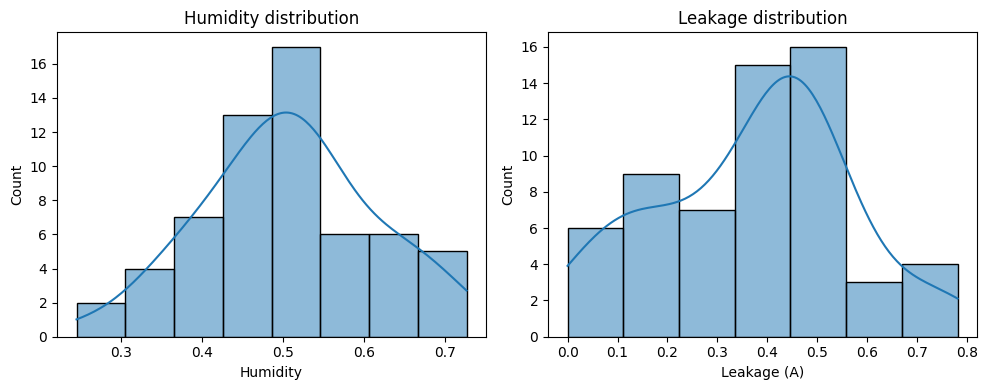

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(data=df, x='humidity', kde=True)
plt.xlabel('Humidity')
plt.ylabel('Count')
plt.title('Humidity distribution')

plt.subplot(1,2,2)
sns.histplot(data=df, x='leakage_A', kde=True)
plt.xlabel('Leakage (A)')
plt.ylabel('Count')
plt.title('Leakage distribution')

plt.tight_layout()
plt.show()

**Result and interpretation**

The humidity distribution is concentrated around 0.5 with truncation at 0 and 1, consistent with the truncated Normal simulation. The leakage_A distribution is not really unimodal, main peak centered near the theoretical relation $$(0.2 + 0.5*\text{humidity})$$, with additional spread due to lot effects and residual noise.

### 1. Concept: humidity‑specific ICC with random slope

With lot‑level random intercept $b_{0j}$ and random slope $b_{1j}$, conditional on humidity $x$ you have

$$
\text{Var}(Y_{ij}\mid x) = \sigma_\epsilon^2 + \text{Var}(b_{0j} + b_{1j} x)
$$

$$
\text{Cov}(Y_{ij}, Y_{i'j} \mid x) = \text{Var}(b_{0j} + b_{1j} x)
$$

so a natural “ICC at humidity $x$” is

$$
\text{ICC}(x) = \frac{\text{Var}(b_{0j} + b_{1j} x)}{\text{Var}(b_{0j} + b_{1j} x) + \sigma_\epsilon^2}.
$$

If you (for now) ignore any intercept–slope covariance, then

$$
\text{Var}(b_{0j} + b_{1j} x) \approx \sigma_{b0}^2 + x^2 \sigma_{b1}^2.
$$

So

$$
\text{ICC}(x) \approx \frac{\sigma_{b0}^2 + x^2 \sigma_{b1}^2}{\sigma_{b0}^2 + x^2 \sigma_{b1}^2 + \sigma_\epsilon^2}.
$$

The job of the ANOVA step is to estimate $\sigma_{b0}^2$, $\sigma_{b1}^2$, and $\sigma_\epsilon^2$ from residuals after removing the *global* line.

In [5]:

# 1. Fit pooled OLS (already in notebook, repeated here for clarity)
ols_model = smf.ols("leakage_A ~ humidity", data=df).fit()
df["resid_ols"] = ols_model.resid

# 2. For each lot, regress residuals on humidity to estimate lot-specific b0_j, b1_j
lot_coefs = []

for lot_id, g in df.groupby("lot"):
    # Regress residuals on humidity within this lot
    lot_fit = smf.ols("resid_ols ~ humidity", data=g).fit()
    b0_j = lot_fit.params["Intercept"]
    b1_j = lot_fit.params["humidity"]
    # Within-lot residual variance for this lot
    sigma_eps2_j = np.mean(lot_fit.resid**2)
    lot_coefs.append(
        {"lot": lot_id, "b0_hat": b0_j, "b1_hat": b1_j, "sigma_eps2_hat": sigma_eps2_j}
    )

lot_coefs = pd.DataFrame(lot_coefs)

# 3. ANOVA-style variance components at lot level
sigma_b0_sq = lot_coefs["b0_hat"].var(ddof=1)
sigma_b1_sq = lot_coefs["b1_hat"].var(ddof=1)
sigma_eps_sq = lot_coefs["sigma_eps2_hat"].mean()  # average within-lot residual variance

print("sigma_b0^2 (between-lot intercept)  :", sigma_b0_sq)
print("sigma_b1^2 (between-lot slope)      :", sigma_b1_sq)
print("sigma_eps^2 (within-lot residual)   :", sigma_eps_sq)

# 4. Define humidity-specific ICC function (ignoring intercept–slope covariance)
def icc_at_x(x, sigma_b0_sq, sigma_b1_sq, sigma_eps_sq):
    num = sigma_b0_sq + (x**2) * sigma_b1_sq
    den = num + sigma_eps_sq
    return num / den

# Example: ICC at some representative humidities
for x in [0.3, 0.5, 0.7]:
    icc_x = icc_at_x(x, sigma_b0_sq, sigma_b1_sq, sigma_eps_sq)
    print(f"ICC at humidity x = {x:.1f}: {icc_x:.3f}")

sigma_b0^2 (between-lot intercept)  : 0.12793881802817098
sigma_b1^2 (between-lot slope)      : 0.4769598396735472
sigma_eps^2 (within-lot residual)   : 0.005229745695224964
ICC at humidity x = 0.3: 0.970
ICC at humidity x = 0.5: 0.979
ICC at humidity x = 0.7: 0.986


> We can see there might be some lot-to-lot variation. Thus it is reasonable to try a random slope/intercept model

**Code: visualize leakage and yield by lot**

The next cell draws a scattergram of leakage_A and Humidity to detect trends, it also shows box plots of the per lot distributions for lot-to-lot variation and to motivate random intercept

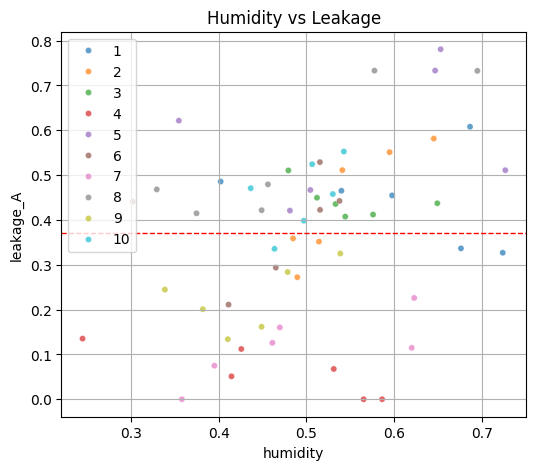

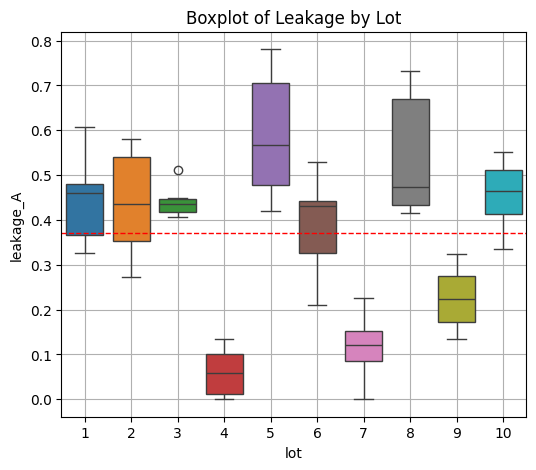

In [6]:

# --- Scatterplot of features --
plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=df,
    x="humidity", y="leakage_A", hue='lot', 
    palette='tab10', alpha=0.7, s=20
)
plt.axhline(lot_summary['mean_leakage'].mean(), color='red', linestyle='--', linewidth=1)
plt.title("Humidity vs Leakage")
plt.legend()
plt.grid(True)
plt.show()

# -- Box plot visualisation of lot-to-lot variation --
plt.figure(figsize=(6,5))
sns.boxplot(data=df, x='lot', y='leakage_A', hue='lot', 
            palette='tab10', legend=False)
plt.axhline(lot_summary['mean_leakage'].mean(), color='red', linestyle='--', linewidth=1)
plt.title('Boxplot of Leakage by Lot')
plt.grid(True)
plt.show()


**Result and interpretation**

The plot shows that some lots sit systematically above or below the global leakage pattern, even after accounting for humidity, indicating persistent between‑lot differences. This is exactly the kind of structure a random intercept model is designed to capture, instead of forcing a single intercept for all lots.

## 4. Baseline pooled linear model

We now fit a **baseline linear regression** of leakage_A on humidity that **ignores lot structure** and treats all wafers as independent draws from a single population. This model estimates a global intercept and slope and serves as a reference for evaluating the value of adding lot‑level random effects.

**Code: fit pooled OLS model leakage_A ~ humidity**

The next cell fits an ordinary least squares (OLS) regression of leakage_A on humidity, computes fitted values and residuals, and attaches them to the data frame. We then inspect a few rows to confirm that predictions and residuals look reasonable.

                            OLS Regression Results                            
Dep. Variable:              leakage_A   R-squared:                       0.140
Model:                            OLS   Adj. R-squared:                  0.125
Method:                 Least Squares   F-statistic:                     9.464
Date:                Mon, 27 Apr 2026   Prob (F-statistic):            0.00320
Time:                        13:24:47   Log-Likelihood:                 18.291
No. Observations:                  60   AIC:                            -32.58
Df Residuals:                      58   BIC:                            -28.39
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0253      0.115      0.221      0.8

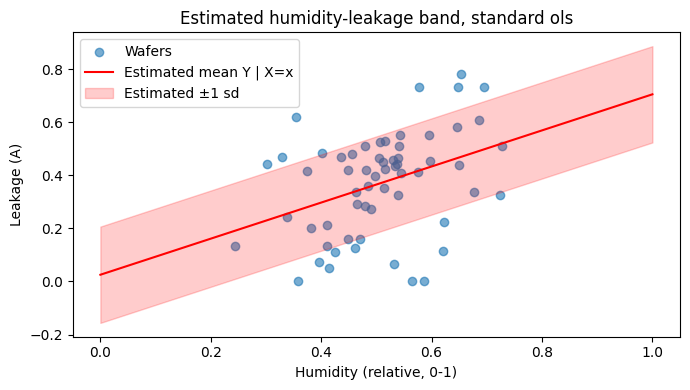

In [7]:
import statsmodels.formula.api as smf

# Baseline regression: leakage_A ~ humidity
model = smf.ols('leakage_A ~ humidity', data=df).fit()
print(model.summary())


# Scatter of observed data
plt.figure(figsize=(7, 4))
plt.scatter(df['humidity'], df['leakage_A'], alpha=0.6, label='Wafers')

# Estimated mean and ±1 sd band
x_grid = np.linspace(0, 1, 100)
X_pred = pd.DataFrame({'humidity': x_grid})
y_ols_hat = model.predict(X_pred)
sd_ols_hat = np.sqrt(model.mse_resid)


plt.plot(x_grid, y_ols_hat, color='red', label='Estimated mean Y | X=x')
plt.fill_between(x_grid,
                 y_ols_hat - sd_ols_hat,
                 y_ols_hat + sd_ols_hat,
                 color='red', alpha=0.2, label='Estimated ±1 sd')

plt.xlabel('Humidity (relative, 0-1)')
plt.ylabel('Leakage (A)')
plt.title('Estimated humidity-leakage band, standard ols')
plt.legend()
plt.tight_layout()
plt.show()

**Result and interpretation**

The estimated intercept and slope are close to the true generating values of 0.2 and 0.5, confirming that the pooled model recovers the global linear trend between humidity and leakage. Residuals are mean‑zero overall, but plotting them by lot (or inspecting summaries by lot) reveals that some lots have systematically positive or negative residuals.

These systematic lot‑level residual patterns show that the pooled model is missing an important source of structure: between‑lot shifts in leakage that should be modeled as random intercepts rather than left in the residual noise.

**Code: plot residuals by lot under the pooled model**

The next cell visualizes residuals from the pooled OLS model grouped by lot, for example via boxplots or scatterplots.

In [8]:
# Predicted leakage and residuals
df['leakage_pred'] = model.predict(df)
df['residual'] = df['leakage_A'] - df['leakage_pred']

df[['humidity', 'leakage_A', 'leakage_pred', 'residual']].head()

,humidity,leakage_A,leakage_pred,residual
0,0.676405,0.336512,0.485241,-0.148729
1,0.540016,0.464970,0.392509,0.072462
2,0.597874,0.454601,0.431847,0.022755
3,0.724089,0.326721,0.517661,-0.190940
4,0.686756,0.607782,0.492278,0.115504


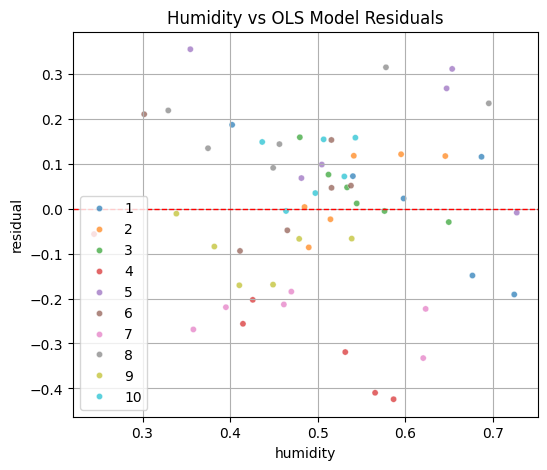

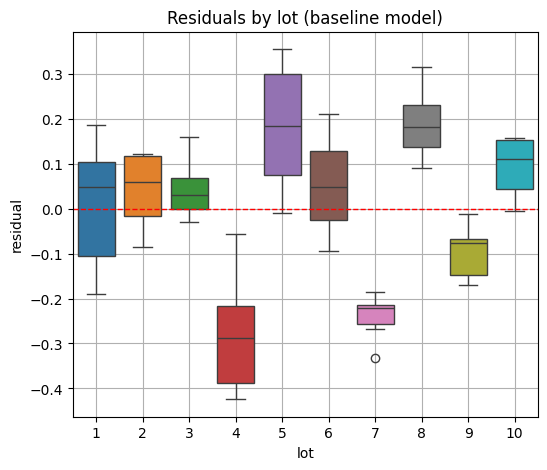

<Figure size 500x500 with 0 Axes>

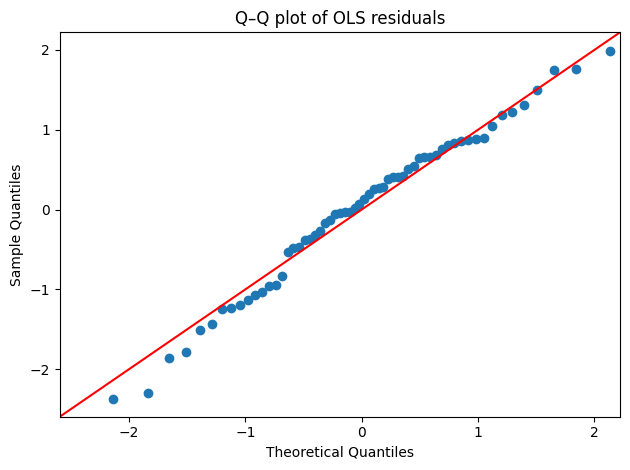

In [9]:
import statsmodels.api as sm
from scipy.stats import norm


# Residuals vs humidity
plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=df,
    x="humidity", y="residual", hue='lot', 
    palette='tab10', alpha=0.7, s=20
)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title("Humidity vs OLS Model Residuals")
plt.legend()
plt.grid(True)
plt.show()


# ── Box plot visualisation residuals by lot ────────────────────────────────────────
plt.figure(figsize=(6,5))
sns.boxplot(data=df, x='lot', y='residual', hue='lot', 
            palette='tab10', legend=False)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Residuals by lot (baseline model)')
plt.grid(True)
plt.show()


# OLS residuals
resid_ols = model.resid   # or ols_model.resid

plt.figure(figsize=(5, 5))
sm.qqplot(resid_ols, dist=norm, line='45', fit=True)
plt.title('Q–Q plot of OLS residuals')
plt.tight_layout()
plt.show()


**Result and interpretation**

Residuals cluster above or below zero for specific lots, indicating that some lots are consistently under‑ or over‑predicted by the global line. This pattern violates the assumption that residuals are identically distributed and uncorrelated within lots, which motivates the move to a mixed model with lot‑specific random intercepts.

## 5. Random Intercept Model



In [10]:
import statsmodels.formula.api as smf

# df: columns 'leakage_A', 'humidity', 'lot' as before

ols_model = smf.ols('leakage_A ~ humidity', data=df).fit()

alpha_hat = ols_model.params['Intercept']
beta_hat = ols_model.params['humidity']
sigma_total_hat = np.sqrt(ols_model.mse_resid)  # sqrt of residual variance

print("alpha_hat =", alpha_hat)
print("beta_hat  =", beta_hat)
print("sigma_total_hat =", sigma_total_hat)

alpha_hat = 0.025349530949397805
beta_hat  = 0.6799047308386015
sigma_total_hat = 0.1814382023273955


So from OLS alone you already have an estimate of $\alpha, \beta,$ and $\sigma_b^2 + \sigma^2$.

## 2. Decompose total variance into between‑lot and within‑lot pieces

Now use the residuals from that regression to estimate $\sigma_b^2$ and $\sigma^2$ separately, exploiting the lot structure. This mirrors ANOVA/random‑effects logic.

### 2.1. Get residuals from the OLS fit

### 2.2. Compute between‑lot and within‑lot variances

Think of $e_{i\ell} = b_\ell + \varepsilon_{i\ell}$ as what’s left after removing the regression line.

- Between‑lot: how much the **mean residual** differs between lots → estimate of $\sigma_b^2$.
- Within‑lot: how much residuals vary inside each lot → estimate of $\sigma^2$.

A simple method‑of‑moments style calculation:

In [11]:
# 2.1 Residuals from OLS fit
df["resid_ols"] = ols_model.resid

# 2.2 For each lot, regress residuals on humidity to get b0_i, b1_i
lot_coefs = []

for lot_id, g in df.groupby("lot"):
    lot_fit = smf.ols("resid_ols ~ humidity", data=g).fit()
    b0_i = lot_fit.params["Intercept"]     # lot-level intercept deviation
    b1_i = lot_fit.params["humidity"]      # lot-level slope deviation
    sigma_eps2_i = np.mean(lot_fit.resid**2)  # within-lot residual variance
    lot_coefs.append(
        {
            "lot": lot_id,
            "b0_hat": b0_i,
            "b1_hat": b1_i,
            "sigma_eps2_hat": sigma_eps2_i,
        }
    )

lot_coefs = pd.DataFrame(lot_coefs)

# 2.3 Method-of-moments variance components
sigma_b0_sq_hat = lot_coefs["b0_hat"].var(ddof=1)
sigma_b1_sq_hat = lot_coefs["b1_hat"].var(ddof=1)
sigma_eps_sq_hat = lot_coefs["sigma_eps2_hat"].mean()

print("sigma_b0^2_hat (between-lot intercept) :", sigma_b0_sq_hat)
print("sigma_b1^2_hat (between-lot slope)     :", sigma_b1_sq_hat)
print("sigma_eps^2_hat (residual)             :", sigma_eps_sq_hat)
print("check total sigma^2                     :", sigma_total_hat**2)
print("b0^2 + b1^2*E[X^2] + eps^2              :",
      sigma_b0_sq_hat + sigma_b1_sq_hat * (df["humidity"]**2).mean() + sigma_eps_sq_hat)

sigma_b0^2_hat (between-lot intercept) : 0.12793881802817098
sigma_b1^2_hat (between-lot slope)     : 0.4769598396735472
sigma_eps^2_hat (residual)             : 0.005229745695224964
check total sigma^2                     : 0.0329198212637969
b0^2 + b1^2*E[X^2] + eps^2              : 0.26145079227904316


In [12]:
from scipy.stats import norm

def distYhat_given_x_random_slope(x):
    # humidity-specific total variance
    var_x = sigma_b0_sq_hat + (x**2) * sigma_b1_sq_hat + sigma_eps_sq_hat
    sd_x = np.sqrt(var_x)
    mean_x = alpha_hat + beta_hat * x
    return norm(loc=mean_x, scale=sd_x)


Now, with random intercept and slope, for a given humidity $x$:

$$
Y \mid X = x \sim \mathcal{N}\left(\hat\alpha + \hat\beta x,\ 
\sigma_{b0}^2 + x^2 \sigma_{b1}^2 + \sigma_\epsilon^2\right).
$$

We have estimated our parameters from the data and the Y distribution (in the function dist_Y_hat_given) by assuming random intercept. Let's look at some predictions

In [13]:
# Example: yield probabilities at a few humidities
threshold = 0.6
for x in [0.3, 0.5, 0.7]:
    d = distYhat_given_x_random_slope(x)
    p_high = 1 - d.cdf(threshold)
    print(f"Humidity {x:.1f}   P(Y >= {threshold:.1f} A | X=x) ≈ {p_high:.3f}")

Humidity 0.3   P(Y >= 0.6 A | X=x) ≈ 0.189
Humidity 0.5   P(Y >= 0.6 A | X=x) ≈ 0.320
Humidity 0.7   P(Y >= 0.6 A | X=x) ≈ 0.435


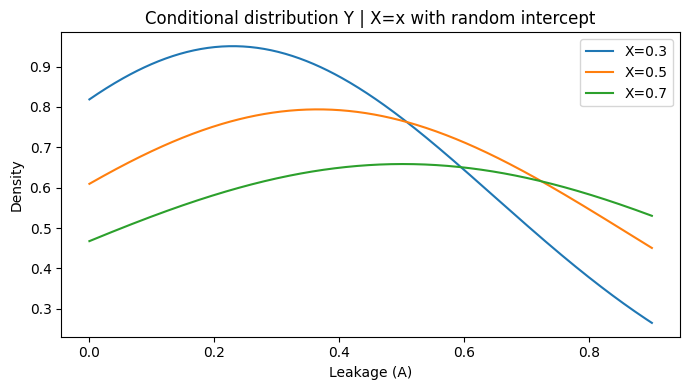

In [14]:
x_vals = np.array([0.3, 0.5, 0.7])        # three humidity levels
colors = ['tab:blue', 'tab:orange', 'tab:green']

y_grid = np.linspace(0.0, 0.9, 400)       # leakage axis

plt.figure(figsize=(7, 4))
for x, c in zip(x_vals, colors):
    dist = distYhat_given_x_random_slope(x)
    pdf_vals = dist.pdf(y_grid)
    plt.plot(y_grid, pdf_vals, color=c, label=f'X={x:.1f}')

plt.xlabel('Leakage (A)')
plt.ylabel('Density')
plt.title('Conditional distribution Y | X=x with random intercept')
plt.legend()
plt.tight_layout()
plt.show()

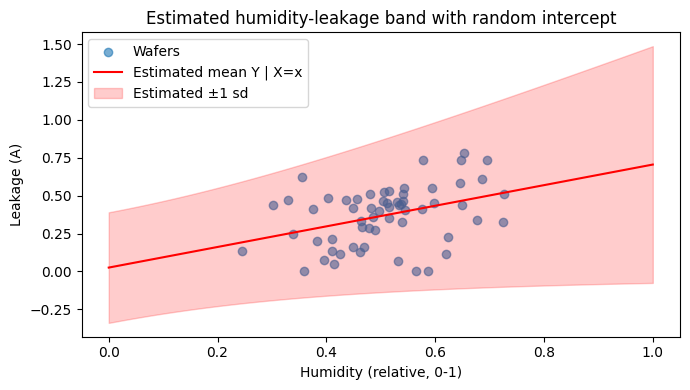

/tmp/ipykernel_40919/1077287112.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


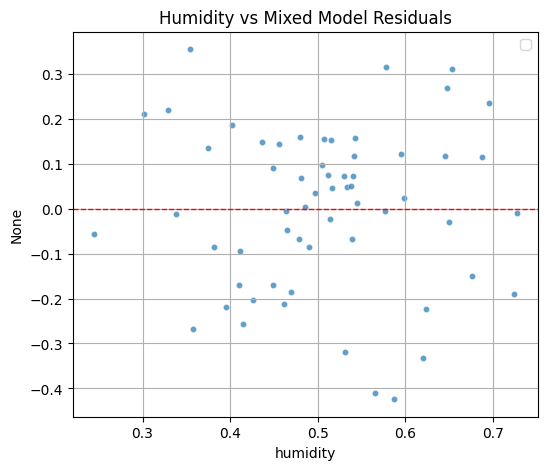

<Figure size 500x500 with 0 Axes>

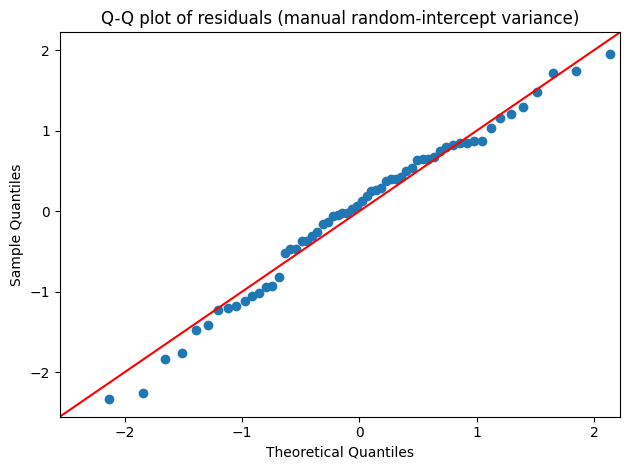

In [15]:
# Scatter of observed data
plt.figure(figsize=(7, 4))
plt.scatter(df['humidity'], df['leakage_A'], alpha=0.6, label='Wafers')


# Estimated mean and ±1 sd band
x_grid = np.linspace(0, 1, 100)
mean_hat = alpha_hat + beta_hat * x_grid
sd_hat = np.sqrt(sigma_b0_sq_hat + (x_grid**2) * sigma_b1_sq_hat + sigma_eps_sq_hat)
mixed_residual = df['leakage_A'] - (alpha_hat + beta_hat*df['humidity'])


plt.plot(x_grid, mean_hat, color='red', label='Estimated mean Y | X=x')
plt.fill_between(x_grid,
                 mean_hat - sd_hat,
                 mean_hat + sd_hat,
                 color='red', alpha=0.2, label='Estimated ±1 sd')

plt.xlabel('Humidity (relative, 0-1)')
plt.ylabel('Leakage (A)')
plt.title('Estimated humidity-leakage band with random intercept')
plt.legend()
plt.tight_layout()
plt.show()


# Residuals vs humidity
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x=df['humidity'], y=mixed_residual, 
    alpha=0.7, s=20
)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title("Humidity vs Mixed Model Residuals")
plt.legend()
plt.grid(True)
plt.show()


# Standardize by the *manual* total sd from variance decomposition
resid_std = mixed_residual / sigma_total_hat

plt.figure(figsize=(5, 5))
# Compare to standard Normal; we scaled residuals ourselves
sm.qqplot(resid_std, dist=norm, line='45', fit=False)
plt.title('Q-Q plot of residuals (manual random-intercept variance)')
plt.tight_layout()
plt.show()

## 6. Comparing models on new predictions

We now compare the baseline pooled model and the random‑intercept model on **new prediction tasks**, such as predicting leakage for wafers from a new lot (with no past wafers) or for new humidity conditions. For a truly new lot, the mixed model uses a random intercept of zero (the prior mean), so its predictions coincide with the global fixed‑effect line, but uncertainty decomposition differs.

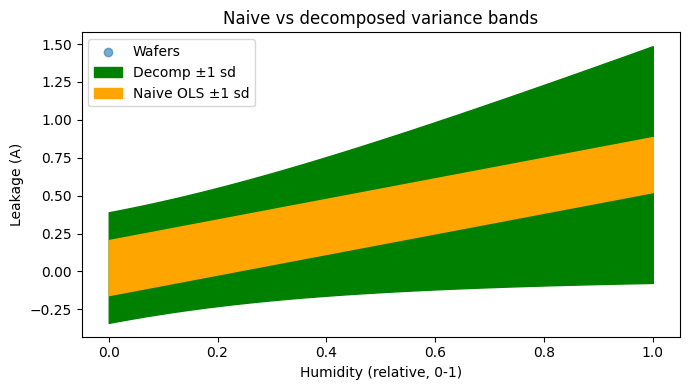

In [16]:
import matplotlib.pyplot as plt

# alpha_hat and beta_hat from the ols model

x_grid = np.linspace(0, 1, 100)
mean_hat = alpha_hat + beta_hat * x_grid

sd_ols = sd_ols_hat
sd_decomp = np.sqrt(
    sigma_b0_sq_hat + (x_grid ** 2) * sigma_b1_sq_hat + sigma_eps_sq_hat
)

plt.figure(figsize=(7, 4))

# Data
plt.scatter(df['humidity'], df['leakage_A'], alpha=0.6, label='Wafers')


# Decomposition band
plt.fill_between(x_grid,
                 mean_hat - sd_decomp,
                 mean_hat + sd_decomp,
                 color='green', alpha=1, label='Decomp ±1 sd')

# Naive OLS band
plt.fill_between(x_grid,
                 mean_hat - sd_ols,
                 mean_hat + sd_ols,
                 color='orange', alpha=1, label='Naive OLS ±1 sd')

# # True band (optional, only for simulation comparison)
# true_sd = np.sqrt(true_sigma_b**2 + true_sigma_eps**2)
# plt.fill_between(x_grid,
#                  mean_hat - true_sd,
#                  mean_hat + true_sd,
#                  color='blue', alpha=1, label='True ±1 sd')

plt.xlabel('Humidity (relative, 0-1)')
plt.ylabel('Leakage (A)')
plt.title('Naive vs decomposed variance bands')
plt.legend()
plt.tight_layout()
plt.show()

> As expected the random intercept standard deviation is larger than the basic ols model

**Compare Models**

Use log-likelihood and AIC/BIC to compare models although for predicting new data the models are the same and the only difference is constant estimation

In [17]:
import statsmodels.api as sm
from scipy.stats import chi2


# --- 2. Fit basic model: OLS (no random intercept) ---
ols_train = smf.ols('leakage_A ~ humidity', data=df).fit()

# Random intercept + slope by lot
mixed_train = sm.MixedLM.from_formula(
    "leakage_A ~ humidity",
    groups="lot",
    re_formula="1 + humidity",
    data=df,
).fit(reml=False)

# Compare models with log-likelihood
llbasic = ols_train.llf
llmixed = mixed_train.llf

LR = 2 * (llmixed - llbasic)
print("LR statistic", LR)
pnaive = 1 - chi2.cdf(LR, df=1)
print("Naive p-value chi2_1", pnaive)

# Compare models with AIC/BIC
print("\n=== Information criteria on training data ===")
print(f"OLS (no random effects):  AIC = {ols_train.aic:.3f}, BIC = {ols_train.bic:.3f}")
print(f"MixedLM random intercept: AIC = {mixed_train.aic:.3f}, BIC = {mixed_train.bic:.3f}")


LR statistic 48.336956397910384
Naive p-value chi2_1 3.5892400163106686e-12

=== Information criteria on training data ===
OLS (no random effects):  AIC = -32.582, BIC = -28.394
MixedLM random intercept: AIC = -72.919, BIC = -60.353


**Code: generate new scenarios and predict with both models**

The next cell constructs a small set of new wafer scenarios (for example, several humidity values, possibly for a new lot ID) and computes predicted leakage (and optionally yield probabilities) under both the baseline OLS model and the mixed model.

In [18]:
# 4. New test data (same as before)
np.random.seed(1)
ntestlots = 10
ntestperlot = 20
N = ntestlots * ntestperlot

lotstest = np.repeat(np.arange(1, ntestlots + 1), ntestperlot)
humiditytest = np.clip(np.random.normal(0.5, 0.1, N), 0, 1)

# One b0_i, b1_i per lot
b0_true = np.random.normal(0.0, true_sigma_b0, ntestlots)
b1_true = np.random.normal(0.0, true_sigma_b1, ntestlots)

# Construct per-wafer lot effects
loteffect_true = b0_true[lotstest - 1] + b1_true[lotstest - 1] * humiditytest

base_true = true_alpha + true_beta * humiditytest
leakagetest = base_true + loteffect_true + np.random.normal(0.0, true_sigma_eps, N)

test_df = pd.DataFrame(
    {
        "lot": lotstest,
        "humidity": humiditytest,
        "leakage_A": leakagetest,
    }
)

In [19]:
# --- 5. Predict on test data ---
# OLS predictions
test_df['pred_ols'] = ols_train.predict(test_df)

# Mixed model fixed-effects predictions (no lot-specific random effects for new lots)
fe_params = mixed_train.fe_params  # intercept and humidity coefficient
test_df['pred_mixed_fe'] = fe_params['Intercept'] + fe_params['humidity'] * test_df['humidity']

In [20]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

rmse_ols = rmse(test_df['leakage_A'], test_df['pred_ols'])
rmse_mixed_fe = rmse(test_df['leakage_A'], test_df['pred_mixed_fe'])

print("Test RMSE OLS       =", rmse_ols)
print("Test RMSE Mixed (FE)=", rmse_mixed_fe)

Test RMSE OLS       = 0.26998219804211926
Test RMSE Mixed (FE)= 0.2708963173151577


**Result and interpretation**


## 7. Comparing models with partial lot data (BLUP)

In many practical situations we see a few wafers from a lot and want to decide early whether that lot is at risk. Here, the random‑intercept model has an advantage: it can use the observed wafers to compute a **BLUP** for the lot’s random intercept and adjust predictions for the remaining wafers accordingly, whereas the pooled model cannot.

### 1. Model and notation

***

### 2. Joint density and posterior via Bayes

***


### 3. “Used when we sample lots (or populations) rather than measure everything?”


***

**Code: simulate partial observations per lot and compute BLUP‑based predictions**

The next cell simulates scenarios where only a subset of wafers per lot are observed, fits or reuses the mixed model, and then computes BLUP‑based predictions for the remaining wafers. We contrast these with predictions from the pooled model, which does not differentiate lots with partial data.

In [21]:
# --- BLUP demo for an existing lot ---

# Random intercept + slope by lot
mixed_train = sm.MixedLM.from_formula(
    "leakage_A ~ humidity",
    groups="lot",
    re_formula="1 + humidity",
    data=df,
).fit(reml=False)

# 1. Choose an existing lot we have BLUPs for
existing_lots = list(mixed_train.random_effects.keys())
lotid = existing_lots[4]  # or any lot you want to illustrate

print("Using lot", lotid)

# 2. BLUPs for intercept and slope for this lot
bhat_vec = np.asarray(mixed_train.random_effects[lotid])  # shape (2,)
b0_hat_lot = bhat_vec[0]
b1_hat_lot = bhat_vec[1]

print("BLUP b0 for lot", lotid, ":", b0_hat_lot)
print("BLUP b1 for lot", lotid, ":", b1_hat_lot)

# 3. Lot-specific OLS for reference
lot_df = df[df["lot"] == lotid].copy()

lot_ols = smf.ols("leakage_A ~ humidity", data=lot_df).fit()
alpha_i_hat = lot_ols.params["Intercept"]
beta_i_hat = lot_ols.params["humidity"]
sigma_i_hat = lot_ols.resid.std(ddof=1)

print("Lot-specific OLS alpha_i hat:", alpha_i_hat)
print("Lot-specific OLS beta_i hat :", beta_i_hat)
print("Lot-specific residual sd    :", sigma_i_hat)


# 4. Simulate new wafers from this lot's OLS line
n_new = 30
x_new = np.linspace(0, 1, n_new)

y_new = alpha_i_hat + beta_i_hat * x_new + np.random.normal(0.0, sigma_i_hat, size=n_new)

new_lot_df = pd.DataFrame(
    {
        "lot": lotid,
        "wafer": np.arange(df["wafer"].max() + 1, df["wafer"].max() + 1 + n_new),
        "humidity": x_new,
        "leakage_A": y_new,
    }
)
new_lot_df["yieldok"] = (new_lot_df["leakage_A"] <= 0.6).astype(int)
new_lot_df.head()


Using lot 5
BLUP b0 for lot 5 : 0.1226625739348234
BLUP b1 for lot 5 : 0.11460444036462455
Lot-specific OLS alpha_i hat: 0.40849151744988266
Lot-specific OLS beta_i hat : 0.3214589442004794
Lot-specific residual sd    : 0.1400199630986403


,lot,wafer,humidity,leakage_A,yieldok
0,5,7,0.000000,0.376460,1
1,5,8,0.034483,0.645479,0
2,5,9,0.068966,0.378181,1
3,5,10,0.103448,0.336735,1
4,5,11,0.137931,0.740519,0


**Result and interpretation**



In [22]:
# 6. Fixed-effects parameters from the original mixed model
beta0_hat = mixed_train.params["Intercept"]
beta1_hat = mixed_train.params["humidity"]

# 7. Predictions on new wafers using *original* mixed model

# a) Treat as if it were a new lot (fixed effects only)
new_lot_df["pred_FE"] = beta0_hat + beta1_hat * new_lot_df["humidity"]

# b) Use existing-lot BLUP (fixed effects + random effect)
new_lot_df["pred_FE_RE"] = (
    (beta0_hat + b0_hat_lot)
    + (beta1_hat + b1_hat_lot) * new_lot_df["humidity"]
)

# c) Residuals
new_lot_df["res_FE"] = new_lot_df["leakage_A"] - new_lot_df["pred_FE"]
new_lot_df["res_FE_RE"] = new_lot_df["leakage_A"] - new_lot_df["pred_FE_RE"]

rmse_fe = np.sqrt(np.mean(new_lot_df["res_FE"]**2))
rmse_fe_re = np.sqrt(np.mean(new_lot_df["res_FE_RE"]**2))

print("RMSE FE only on new wafers     :", rmse_fe)
print("RMSE FE + BLUP on new wafers   :", rmse_fe_re)

RMSE FE only on new wafers     : 0.2828286060443378
RMSE FE + BLUP on new wafers   : 0.15699049139295562


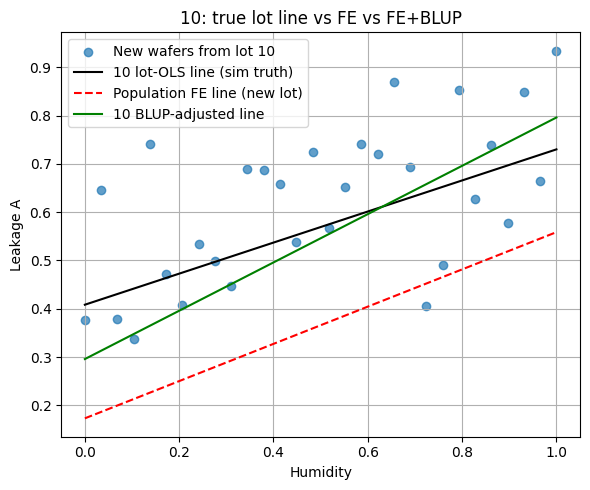

In [23]:
# 8. Prediction lines vs the lot's true (OLS) line

# "True" lot line used for simulation (lot-level OLS)
x_grid = np.linspace(0, 1, 100)
y_true_lot = alpha_i_hat + beta_i_hat * x_grid

# Model fixed-effects line
y_fe = beta0_hat + beta1_hat * x_grid

# Mixed-model BLUP-adjusted line for this lot
# BLUP-adjusted line for this lot
y_fe_re = (beta0_hat + b0_hat_lot) + (beta1_hat + b1_hat_lot) * x_grid

plt.figure(figsize=(6, 5))
plt.scatter(new_lot_df["humidity"], new_lot_df["leakage_A"],
            label=f"New wafers from lot {lot_id}", alpha=0.7)

plt.plot(x_grid, y_true_lot, "k-", label=f"{lot_id} lot-OLS line (sim truth)")
plt.plot(x_grid, y_fe, "r--", label="Population FE line (new lot)")
plt.plot(x_grid, y_fe_re, "g-", label=f"{lot_id} BLUP-adjusted line")

plt.xlabel("Humidity")
plt.ylabel("Leakage A")
plt.title(f"{lot_id}: true lot line vs FE vs FE+BLUP")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

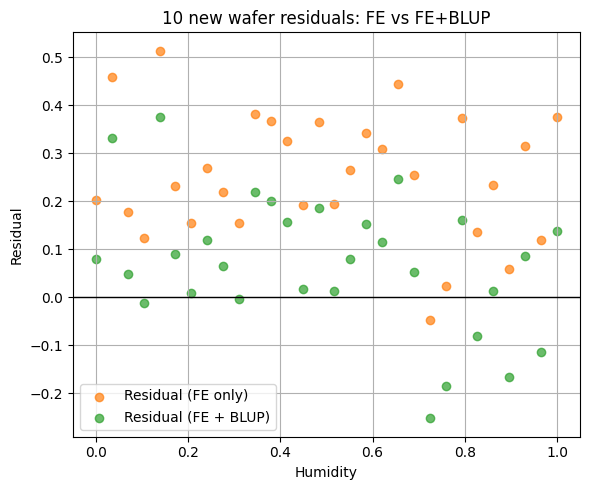

RMSE for FE:  0.25137787307464127
RMSE for FE+BLUP:  0.07141307895750557


In [24]:
plt.figure(figsize=(6, 5))
plt.scatter(new_lot_df["humidity"], new_lot_df["res_FE"],
            label="Residual (FE only)", alpha=0.7, color="tab:orange")
plt.scatter(new_lot_df["humidity"], new_lot_df["res_FE_RE"],
            label="Residual (FE + BLUP)", alpha=0.7, color="tab:green")

plt.axhline(0.0, color="k", linewidth=1)
plt.xlabel("Humidity")
plt.ylabel("Residual")
plt.title(f"{lot_id} new wafer residuals: FE vs FE+BLUP")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Average error
rmse_fe = np.sqrt(np.mean(new_lot_df["res_FE"]**2))
rmse_fe_re = np.sqrt(np.mean(new_lot_df["res_FE_RE"]**2))
print('RMSE for FE: ',new_lot_df["res_FE"].mean())
print('RMSE for FE+BLUP: ',new_lot_df["res_FE_RE"].mean())